# Acrobot

In [ ]:
import gymnasium as gym

env = gym.make("Acrobot-v1", render_mode="rgb_array")
initial_state = env.reset()

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(env.render())

In [ ]:
import torch
import torch.nn as nn

# Policy network: obs (6,) -> action logits (3,)
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(6, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.mlp(x)

policy = Policy()
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

In [7]:
def run_episode(env, max_steps = 500):
    """Run one episode, return lists of log-probs and rewards."""
    obs, _ = env.reset()
    log_probs, rewards = [], []

    for _ in range(max_steps):
        logits = policy(torch.tensor(obs, dtype=torch.float32))
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()

        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)

        if terminated or truncated:
            break

    return log_probs, rewards


def returns(rewards, gamma=0.99):
    """Compute discounted returns G_t for each timestep."""
    G, running = [], 0.0
    for r in reversed(rewards):
        running = r + gamma * running
        G.insert(0, running)
    G = torch.tensor(G, dtype=torch.float32)
    return (G - G.mean()) / (G.std() + 1e-8)  # normalize for stability

In [ ]:
from tqdm.notebook import trange

num_episodes = 500

for episode in trange(num_episodes):
    log_probs, rewards = run_episode(env)
    G = returns(rewards)

    # REINFORCE loss: -sum( G_t * log policy(a_t|s_t) )
    loss = -torch.stack([lp * g for lp, g in zip(log_probs, G)]).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1:4d} | steps: {len(rewards):3d} | total reward: {sum(rewards):.1f}")

# Mountain car

In [1]:
import gymnasium as gym

env = gym.make("MountainCarContinuous-v0", render_mode="rgb_array")
initial_state = env.reset()

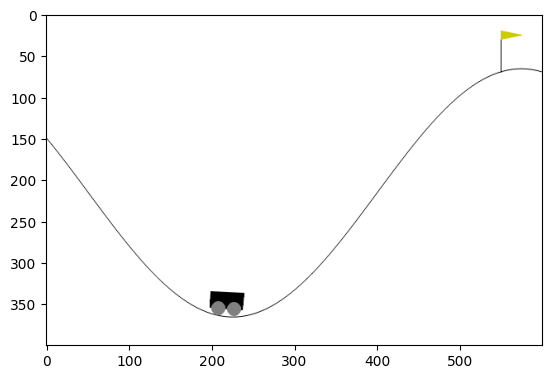

In [2]:
import matplotlib.pyplot as plt

plt.imshow(env.render())

In [3]:
from torch import nn
from reinforce import REINFORCE

policy = nn.Sequential(
    nn.Linear(2, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 1),
    nn.Tanh() # To keep in [-1, 1]
)

baseline = nn.Sequential(
    nn.Linear(2, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 1)
)

rl = REINFORCE(env, policy, discount=0.99, continuous_actions=True, value_net=baseline)

In [ ]:
rl.learn(max_steps=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]